                            Label  Accuracy  Precision  Recall  F1-Score
0                        Any Type      1.00   1.000000     1.0  1.000000
1            Enum Implicit Values      0.80   1.000000     0.6  0.750000
2     Multiple Booleans for State      1.00   1.000000     1.0  1.000000
3  Missing Union Type Abstraction      1.00   1.000000     1.0  1.000000
4             Non-Null Assertions      1.00   1.000000     1.0  1.000000
5           Overly Flexible Props      0.95   0.909091     1.0  0.952381


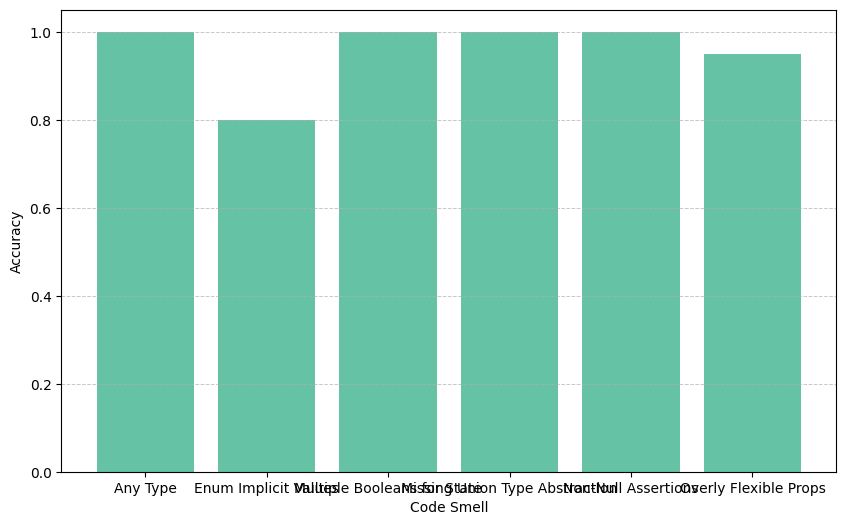

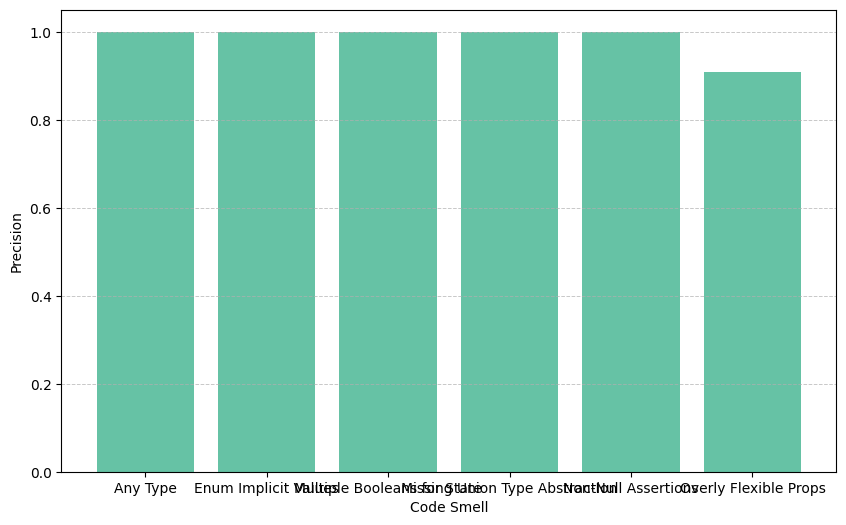

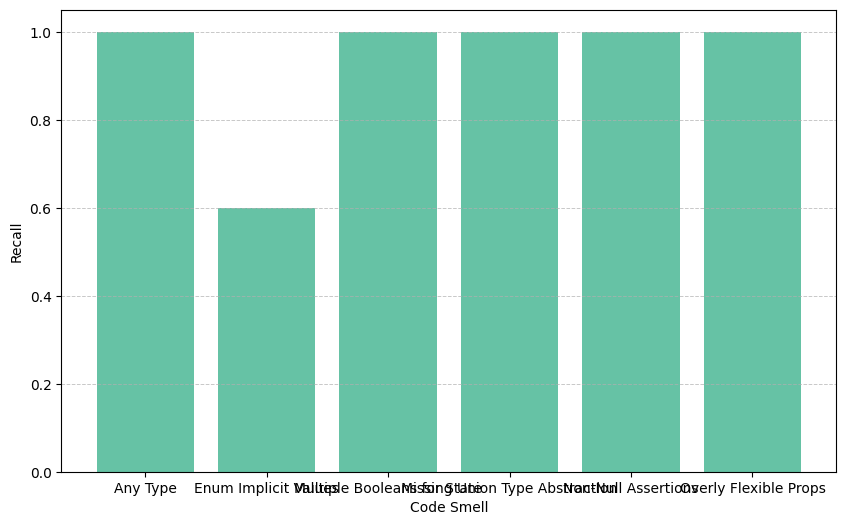

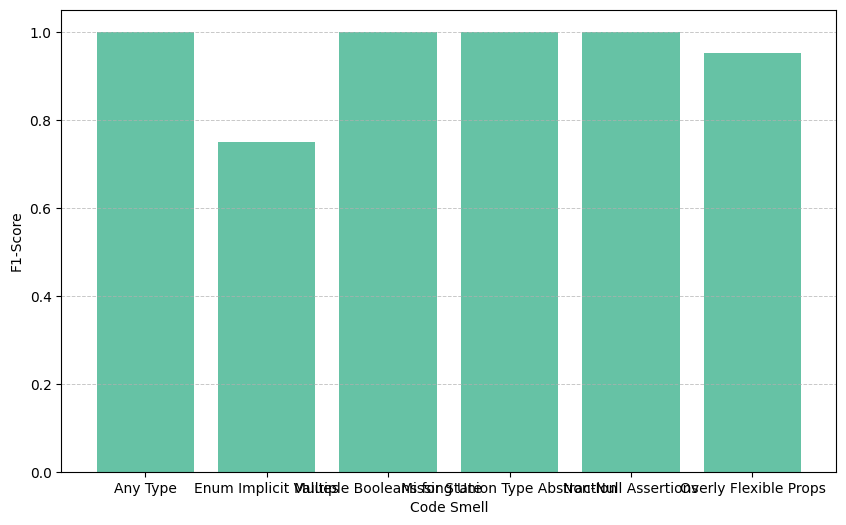

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

csv_files = [
    {'file': './results/ANY.csv', 'label': 'Any Type'},
    {'file': './results/EIV.csv', 'label': 'Enum Implicit Values'},
    {'file': './results/MBS.csv', 'label': 'Multiple Booleans for State'},
    {'file': './results/MUT.csv', 'label': 'Missing Union Type Abstraction'},
    {'file': './results/NNA.csv', 'label': 'Non-Null Assertions'},
    {'file': './results/OFP.csv', 'label': 'Overly Flexible Props'},
]

def calculate_metrics(file_info):
    df = pd.read_csv(file_info['file'])
    y_true = df['y_true']
    y_pred = df['y_pred']

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=1)
    recall = recall_score(y_true, y_pred, zero_division=1)
    f1 = f1_score(y_true, y_pred, zero_division=1)
    
    return {
        'Label': file_info['label'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

results = [calculate_metrics(file_info) for file_info in csv_files]

results_df = pd.DataFrame(results)

print(results_df)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(results_df['Label'], results_df[metric], color='#66c2a5')

    plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.xlabel('Code Smell')
    plt.ylabel(metric)

    plt.show()